In [ ]:
# Install necessary libraries silently. '-q' means quiet mode, suppressing installation output.
!pip install -q kaggle category_encoders xgboost tensorflow seaborn

# Import the 'files' module from google.colab to handle file uploads in Colab environment.
from google.colab import files

# Print a message to the user, instructing them to upload the 'kaggle.json' file.
print("Upload kaggle.json")

# Call the 'upload()' method, which opens a file selection dialog for the user to choose files.
files.upload()

# Create a directory named '.kaggle' within the user's home directory. The '-p' flag ensures
# that parent directories are created if they don't exist and suppresses errors if the directory already exists.
!mkdir -p ~/.kaggle

# Copy the uploaded 'kaggle.json' file to the newly created '~/.kaggle/' directory.
!cp kaggle.json ~/.kaggle/

# Change the permissions of 'kaggle.json' to '600', making it readable and writable only by the owner,
# which is a security best practice for API credentials.
!chmod 600 ~/.kaggle/kaggle.json

# Use the Kaggle API to download the dataset 'dhoogla/cicids2017'.
!kaggle datasets download -d dhoogla/cicids2017

# Unzip the downloaded 'cicids2017.zip' file into the '/content/cicids2017/' directory.
# The '-q' flag means quiet mode, suppressing output from the unzip command.
# The '-d' flag specifies the destination directory for the unzipped contents.
!unzip -q cicids2017.zip -d /content/cicids2017/

# Import the 'os' module for interacting with the operating system, like listing directories.
import os

# Define the directory where the dataset files are extracted.
data_dir = "/content/cicids2017/"

# Loop through each file and directory in the specified 'data_dir'.
for f in os.listdir(data_dir):
    # Print the name of each file or directory found, to confirm extraction.
    print(f)

Upload kaggle.json


Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/dhoogla/cicids2017
License(s): CC-BY-NC-SA-4.0
 68% 155M/227M [00:00<00:00, 1.62GB/s]
100% 227M/227M [00:00<00:00, 1.01GB/s]
Bruteforce-Tuesday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet
DoS-Wednesday-no-metadata.parquet
DDoS-Friday-no-metadata.parquet
Infiltration-Thursday-no-metadata.parquet
Benign-Monday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet


**Signature based: XGBOOST**
The following implementation demonstrates a comprehensive workflow for preprocessing, augmenting, and classifying the CICIDS2017 network intrusion dataset using XGBoost. The workflow includes:

1. **Data Loading and Cleaning:** Reading all dataset files, handling missing and duplicate values, and standardizing labels.

2. **Balancing and Augmentation:** Addressing class imbalance by sampling benign and attack instances, and applying targeted oversampling for underrepresented attack types.

3. **Feature Engineering and Selection:** Applying one-hot encoding, variance thresholding, correlation analysis, and XGBoost-based feature importance to retain informative features.

4. **Dataset Splitting:** Stratified splitting into training, validation, and test sets to ensure representative class distributions.

5. **Model Training:** Configuring an XGBoost classifier with optimized hyperparameters and applying class weights to mitigate imbalanced learning.

6. **Evaluation:** Assessing model performance using confusion matrices and detailed classification reports on both validation and test sets.

This pipeline provides a robust approach for multi-class network intrusion detection, ensuring high-quality data preprocessing, effective feature selection, and reliable evaluation metrics.

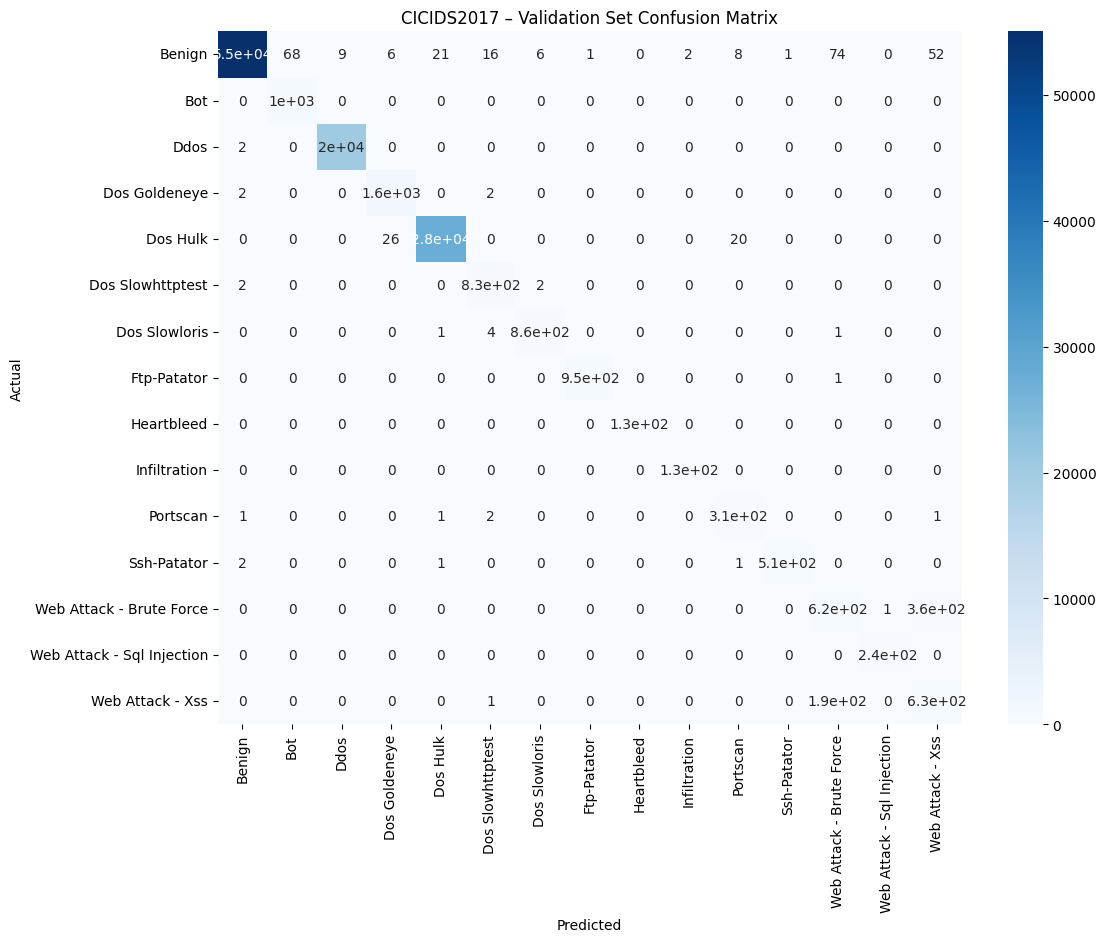

                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00     55311
                       Bot       0.94      1.00      0.97      1030
                      Ddos       1.00      1.00      1.00     20482
             Dos Goldeneye       0.98      1.00      0.99      1646
                  Dos Hulk       1.00      1.00      1.00     27656
          Dos Slowhttptest       0.97      1.00      0.98       836
             Dos Slowloris       0.99      0.99      0.99       862
               Ftp-Patator       1.00      1.00      1.00       949
                Heartbleed       1.00      1.00      1.00       130
              Infiltration       0.99      1.00      0.99       134
                  Portscan       0.91      0.98      0.95       313
               Ssh-Patator       1.00      0.99      1.00       515
  Web Attack - Brute Force       0.70      0.63      0.66       987
Web Attack - Sql Injection       1.00      1.00

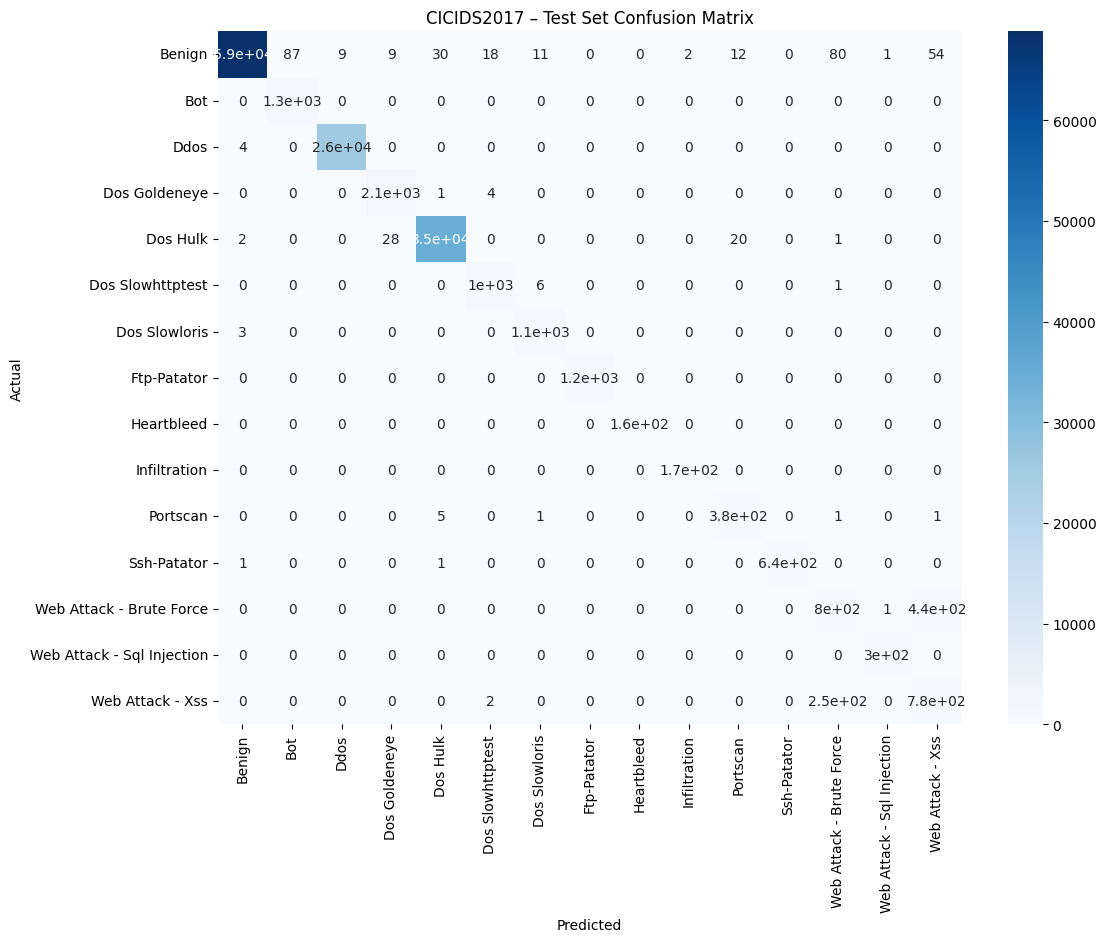

                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00     69139
                       Bot       0.94      1.00      0.97      1288
                      Ddos       1.00      1.00      1.00     25603
             Dos Goldeneye       0.98      1.00      0.99      2057
                  Dos Hulk       1.00      1.00      1.00     34569
          Dos Slowhttptest       0.98      0.99      0.99      1046
             Dos Slowloris       0.98      1.00      0.99      1077
               Ftp-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00       162
              Infiltration       0.99      1.00      0.99       167
                  Portscan       0.92      0.98      0.95       391
               Ssh-Patator       1.00      1.00      1.00       644
  Web Attack - Brute Force       0.70      0.65      0.67      1234
Web Attack - Sql Injection       0.99      1.00

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# Define the directory where the dataset files are located.
DATA_DIR = "/content/cicids2017/"

# Get a list of all files in the data directory that end with '.parquet'.
files = [f for f in os.listdir(DATA_DIR) if f.endswith(".parquet")]

# Initialize an empty list to store individual DataFrames.
dfs = []

# Loop through each parquet file.
for f in files:
    # Read the parquet file into a pandas DataFrame.
    df = pd.read_parquet(os.path.join(DATA_DIR, f))
    # Clean the 'Label' column: convert to string, strip whitespace, replace '' with '-', and title case.
    df["Label"] = df["Label"].astype(str).str.strip().str.replace("", "-", regex=False).str.title()
    # Drop rows with any missing values.
    df.dropna(inplace=True)
    # Drop duplicate rows.
    df.drop_duplicates(inplace=True)
    # Append the processed DataFrame to the list.
    dfs.append(df)

# Concatenate all individual DataFrames into a single DataFrame, ignoring original indices.
df_all = pd.concat(dfs, ignore_index=True)

# Separate the DataFrame into benign and attack traffic based on the 'Label' column.
benign_df = df_all[df_all["Label"] == "Benign"]
attack_df = df_all[df_all["Label"] != "Benign"]

# Find the maximum count of any single attack type.
max_attack = attack_df["Label"].value_counts().max()

# Sample 'Benign' traffic to balance the dataset. Sample 'max_attack * 2' benign instances.
benign_sample = benign_df.sample(n=max_attack*2, random_state=42)

# Concatenate the attack traffic and the sampled benign traffic to create a balanced dataset.
df_balanced = pd.concat([attack_df, benign_sample], ignore_index=True)

# Define an augmentation function to balance specific attack classes.
def augment(label, target):
    # Filter the balanced DataFrame for a specific label.
    df = df_balanced[df_balanced["Label"] == label]
    # If the number of instances for the label is already greater than or equal to the target, return as is.
    if len(df) >= target:
        return df
    # Otherwise, sample with replacement to reach the target number of instances.
    return df.sample(n=target, replace=True, random_state=42)

# List of augmented parts for specific attack types to ensure sufficient representation.
augmented_parts = [
    augment("Bot", 5000),
    augment("Web Attack - Brute Force", 4700),
    augment("Web Attack - Xss", 4500),
    augment("Web Attack - Sql Injection", 1500),
    augment("Heartbleed", 800),
    augment("Infiltration", 800),
]

# Concatenate the balanced DataFrame with the augmented parts to create the final dataset.
df_final = pd.concat([df_balanced] + augmented_parts, ignore_index=True)

# Separate features (X) and target (y).
y = df_final["Label"]
X = df_final.drop(columns=["Label"])

# Perform one-hot encoding on categorical features in X, dropping the first category to avoid multicollinearity.
X = pd.get_dummies(X, drop_first=True)

# Initialize LabelEncoder for converting string labels to numerical format.
le = LabelEncoder()

# Fit LabelEncoder to the target variable and transform the labels to numerical values.
y_enc = le.fit_transform(y)

# Determine the number of unique classes after encoding.
NUM_CLASSES = len(le.classes_)

# Initialize VarianceThreshold to remove features with low variance (constant features).
vt = VarianceThreshold(0.005)

# Fit VarianceThreshold to X and transform it, removing low-variance features.
X_vt = vt.fit_transform(X)

# Convert the transformed array back to a DataFrame, keeping the column names of selected features.
X_vt = pd.DataFrame(X_vt, columns=X.columns[vt.get_support()])

# Calculate the absolute correlation matrix for the features.
corr = X_vt.corr().abs()

# Select the upper triangle of the correlation matrix, excluding the diagonal.
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Identify columns to drop based on high correlation (greater than 0.97).
drop_cols = [c for c in upper.columns if any(upper[c] > 0.97)]

# Drop the highly correlated columns from the DataFrame.
X_corr = X_vt.drop(columns=drop_cols)

# Initialize an XGBoost Classifier for feature selection (first pass).
xgb_fs = XGBClassifier(
    n_estimators=300, # Number of boosting rounds (trees).
    max_depth=6, # Maximum depth of a tree.
    learning_rate=0.08, # Step size shrinkage to prevent overfitting.
    subsample=0.8, # Subsample ratio of the training instance.
    colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree.
    tree_method="hist", # Use histogram-based algorithm for faster training.
    random_state=42 # Random seed for reproducibility.
)

# Fit the XGBoost model to the data to get feature importances.
xgb_fs.fit(X_corr, y_enc)

# Get feature importances from the fitted model and sort them in descending order.
importances = pd.Series(xgb_fs.feature_importances_, index=X_corr.columns).sort_values(ascending=False)

# Select final features based on importance threshold (greater than 0.003).
X_final = X_corr[importances[importances > 0.003].index]

# Split the data into training (80%) and test (20%) sets, stratified by target variable.
X_train_full, X_test, y_train_full, y_test = train_test_split(X_final, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

# Further split the full training set into training (80%) and validation (20%) sets, stratified.
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)

# Compute class weights to handle class imbalance.
weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)

# Create a dictionary mapping class indices to their computed weights.
class_weights = dict(enumerate(weights))

# Initialize the final XGBoost Classifier with optimized parameters.
xgb_final = XGBClassifier(
    objective="multi:softprob", # Softmax objective for multi-class classification.
    num_class=NUM_CLASSES, # Number of target classes.
    n_estimators=1200, # Number of boosting rounds.
    max_depth=7, # Maximum tree depth.
    learning_rate=0.04, # Learning rate.
    subsample=0.85, # Subsample ratio of the training instance.
    colsample_bytree=0.85, # Subsample ratio of columns.
    reg_alpha=1.0, # L1 regularization term on weights.
    reg_lambda=1.5, # L2 regularization term on weights.
    min_child_weight=5, # Minimum sum of instance weight (hessian) needed in a child.
    tree_method="hist", # Histogram-based algorithm.
    eval_metric="mlogloss", # Evaluation metric for validation data (multiclass logloss).
    random_state=42 # Random seed.
)

# Fit the final XGBoost model to the training data.
xgb_final.fit(
    X_train,
    y_train,
    sample_weight=[class_weights[y] for y in y_train], # Apply class weights to samples.
    eval_set=[(X_val, y_val)], # Validation set for early stopping or evaluation during training.
    verbose=False # Suppress verbose output during training.
)

# Predict labels for the validation set.
y_val_pred = xgb_final.predict(X_val)

# Compute the confusion matrix for the validation set.
cm_val = confusion_matrix(y_val, y_val_pred)

# Create a figure for the heatmap with a specified size.
plt.figure(figsize=(12, 9))

# Generate a heatmap of the validation confusion matrix.
sns.heatmap(cm_val, annot=True, cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)

# Set the title of the plot.
plt.title("CICIDS2017 – Validation Set Confusion Matrix")

# Set the x-axis label.
plt.xlabel("Predicted")

# Set the y-axis label.
plt.ylabel("Actual")

# Display the plot.
plt.show()

# Print the classification report for the validation set, showing precision, recall, f1-score.
print(classification_report(y_val, y_val_pred, target_names=le.classes_, zero_division=0))

# Predict labels for the test set.
y_test_pred = xgb_final.predict(X_test)

# Compute the confusion matrix for the test set.
cm_test = confusion_matrix(y_test, y_test_pred)

# Create a figure for the heatmap with a specified size.
plt.figure(figsize=(12, 9))

# Generate a heatmap of the test confusion matrix.
sns.heatmap(cm_test, annot=True, cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)

# Set the title of the plot.
plt.title("CICIDS2017 – Test Set Confusion Matrix")

# Set the x-axis label.
plt.xlabel("Predicted")

# Set the y-axis label.
plt.ylabel("Actual")

# Display the plot.
plt.show()

# Print the classification report for the test set.
print(classification_report(y_test, y_test_pred, target_names=le.classes_, zero_division=0))

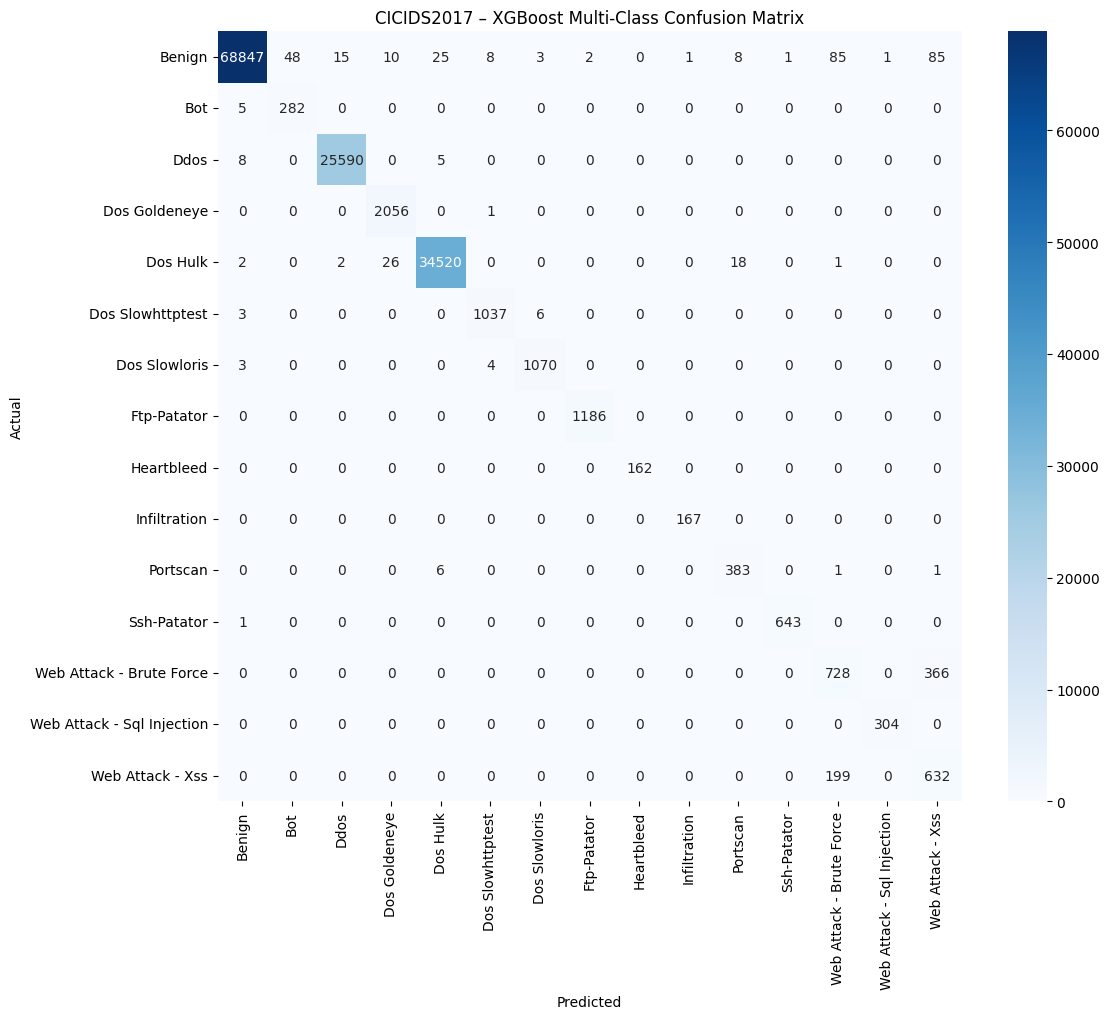

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Note: `y_pred` is not defined in this cell. It should likely be `y_test_pred`
# from the previous cell's execution, but for the purpose of adding comments,
# we assume `y_pred` is meant to be the predictions for the test set.
# cm = confusion_matrix(y_test, y_pred)

# Assuming y_test_pred from the previous cell is intended here.
cm = confusion_matrix(y_test, y_test_pred)

# Create a figure for the heatmap with a specified size.
plt.figure(figsize=(12,10))

# Generate a heatmap of the confusion matrix.
# 'annot=True' displays the actual values on the heatmap.
# 'fmt="d"' formats the annotation values as integers.
# 'cmap="Blues"' sets the color map to shades of blue.
# 'xticklabels' and 'yticklabels' set the labels for x and y axes based on class names.
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

# Set the x-axis label.
plt.xlabel("Predicted")

# Set the y-axis label.
plt.ylabel("Actual")

# Set the title of the plot.
plt.title("CICIDS2017 – XGBoost Multi-Class Confusion Matrix")

# Display the plot.
plt.show()

**Anomaly based detection : Autoencoder**
The following implementation demonstrates a workflow for anomaly detection on the CICIDS2017 network intrusion dataset using an autoencoder. The workflow includes:

1. **Data Loading and Cleaning:** Reading all dataset files, handling duplicates and missing values, and standardizing labels.
2. **Feature Transformation and Scaling:** Applying log transformations to skewed features, one-hot encoding categorical variables, and standardizing all features.
3. **Data Splitting:** Dividing the dataset into training, validation, and test sets, with the autoencoder trained solely on benign traffic to model normal behavior.
4. **Autoencoder Architecture:** Building a fully connected autoencoder with batch normalization and dropout to learn compact representations of benign network traffic.
5. **Training with Early Stopping:** Using the Adam optimizer and Huber loss to train the model, with early stopping based on validation loss.
6. **Anomaly Detection and Evaluation:** Computing reconstruction errors, setting percentile-based thresholds, and evaluating the model on test data using confusion matrices and classification reports.

This pipeline provides a robust approach for unsupervised anomaly detection, allowing identification of network attacks based on deviations from normal traffic patterns.

Training shape: (1581854, 77)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 77)             │        19,789 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,301 (485.55 KB)

 Trainable params: 123,277 (481.55 KB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/100
5562/5562 - 78s - 14ms/step - loss: 0.0194 - val_loss: 0.0059
Epoch 2/100
5562/5562 - 73s - 13ms/step - loss: 0.0082 - val_loss: 0.0043
Epoch 3/100
5562/5562 - 74s - 13ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 4/100
5562/5562 - 83s - 15ms/step - loss: 0.0060 - val_loss: 0.0037
Epoch 5/100
5562/5562 - 72s - 13ms/step - loss: 0.0056 - val_loss: 0.0029
Epoch 6/100
5562/5562 - 74s - 13ms/step - loss: 0.0052 - val_loss: 0.0029
Epoch 7/100
5562/5562 - 73s - 13ms/step - loss: 0.0050 - val_loss: 0.0027
Epoch 8/100
5562/5562 - 73s - 13ms/step - loss: 0.0048 - val_loss: 0.0036
Epoch 9/100
5562/5562 - 73s - 13ms/step - loss: 0.0047 - val_loss: 0.0026
Epoch 10/100
5562/5562 - 73s - 13ms/step - loss: 0.0045 - val_loss: 0.0030
Epoch 11/100
5562/5562 - 73s - 13ms/step - loss: 0.0043 - val_loss: 0.0060
Epoch 12/100
5562/5562 - 72s - 13ms/step - loss: 0.0042 - val_loss: 0.0055
Epoch 13/100
5562/5562 - 83s - 15ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 14/100
5562/5562 - 73s - 13m

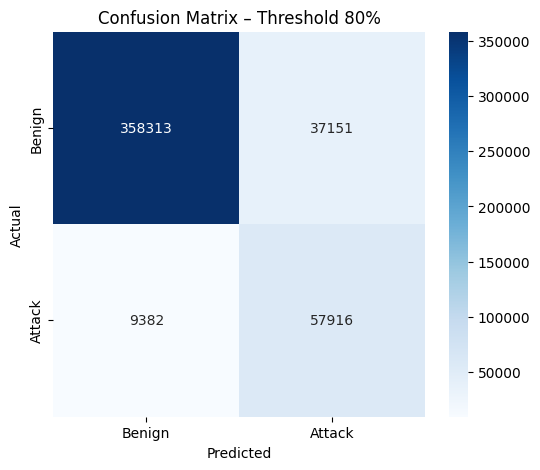

              precision    recall  f1-score   support

      Benign       0.97      0.91      0.94    395464
      Attack       0.61      0.86      0.71     67298

    accuracy                           0.90    462762
   macro avg       0.79      0.88      0.83    462762
weighted avg       0.92      0.90      0.91    462762


=== Threshold = 85% ===
[[377236  18228]
 [ 14001  53297]]


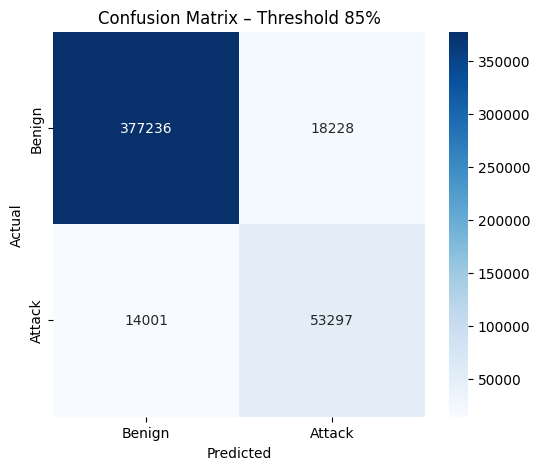

              precision    recall  f1-score   support

      Benign       0.96      0.95      0.96    395464
      Attack       0.75      0.79      0.77     67298

    accuracy                           0.93    462762
   macro avg       0.85      0.87      0.86    462762
weighted avg       0.93      0.93      0.93    462762


=== Threshold = 90% ===
[[392878   2586]
 [ 20438  46860]]


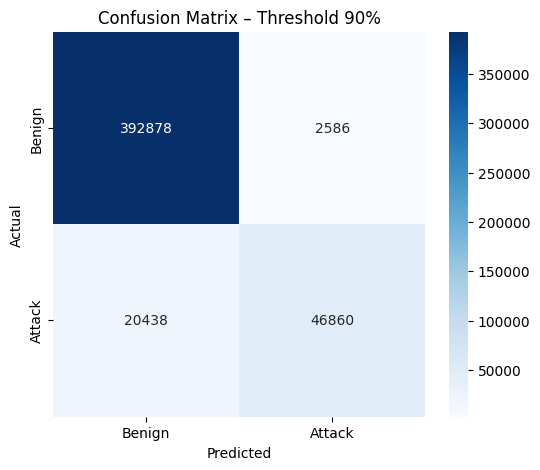

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97    395464
      Attack       0.95      0.70      0.80     67298

    accuracy                           0.95    462762
   macro avg       0.95      0.84      0.89    462762
weighted avg       0.95      0.95      0.95    462762


=== Threshold = 92% ===
[[394687    777]
 [ 28131  39167]]


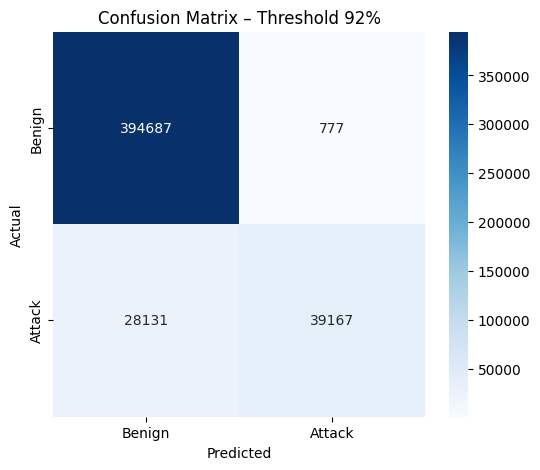

              precision    recall  f1-score   support

      Benign       0.93      1.00      0.96    395464
      Attack       0.98      0.58      0.73     67298

    accuracy                           0.94    462762
   macro avg       0.96      0.79      0.85    462762
weighted avg       0.94      0.94      0.93    462762


=== Threshold = 95% ===
[[395010    454]
 [ 42292  25006]]


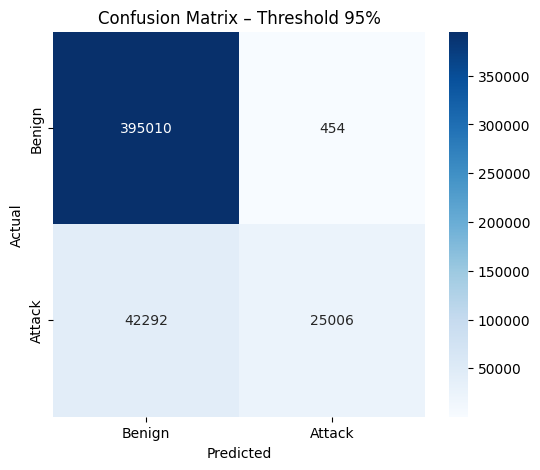

              precision    recall  f1-score   support

      Benign       0.90      1.00      0.95    395464
      Attack       0.98      0.37      0.54     67298

    accuracy                           0.91    462762
   macro avg       0.94      0.69      0.74    462762
weighted avg       0.91      0.91      0.89    462762



In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
import matplotlib.pyplot as plt
import seaborn as sns

# Define the directory containing the data files.
data_dir = "/content/cicids2017/"

# Get a list of all files in the data directory that end with '.parquet'.
files = [f for f in os.listdir(data_dir) if f.endswith(".parquet")]

# Initialize an empty list to store individual DataFrames.
df_list = []

# Loop through each parquet file.
for f in files:
    # Read the parquet file into a pandas DataFrame.
    df = pd.read_parquet(os.path.join(data_dir, f))
    # Clean the 'Label' column: convert to string, strip whitespace, replace '' with '-', and title case.
    df['Label'] = df['Label'].astype(str).str.strip().str.replace('', '-', regex=False).str.title()
    # Drop duplicate rows.
    df.drop_duplicates(inplace=True)
    # Drop rows with any missing values.
    df.dropna(inplace=True)
    # Append the processed DataFrame to the list.
    df_list.append(df)

# Concatenate all individual DataFrames into a single DataFrame, ignoring original indices.
df_all = pd.concat(df_list, ignore_index=True)

# Define columns for which log transformation will be applied.
cols_to_log = ['Fwd Packets Length Total', 'Bwd Packets Length Total', 'Active Mean']

# Apply log1p transformation to specified columns, clipping values to non-negative.
for col in cols_to_log:
    if col in df_all.columns:
        df_all[col] = np.log1p(df_all[col].clip(lower=0))

# Separate features (X) and target (y).
y = df_all['Label']
X = df_all.drop(columns=['Label'])

# Identify categorical columns (object type).
cat_cols = X.select_dtypes(include=['object']).columns

# If there are categorical columns, perform one-hot encoding.
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True) # Drop first to avoid multicollinearity.

# Initialize StandardScaler for feature scaling.
scaler = StandardScaler()

# Fit the scaler to X and transform the features.
X_scaled = scaler.fit_transform(X)

# Split the scaled data into training and test sets, stratified by target.
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Filter the training data to include only 'Benign' samples for autoencoder training (anomaly detection).
X_train = X_train_all[y_train_all == 'Benign']

# Use a small portion of the training data (before filtering for 'Benign') as a validation set for thresholding.
X_val = X_train_all[:10000]

# Print the shape of the training data used for the autoencoder.
print("Training shape:", X_train.shape)

# Define the input dimension for the autoencoder (number of features).
input_dim = X_train.shape[1]

# Define the input layer of the autoencoder.
inp = Input(shape=(input_dim,))

# Encoder part of the autoencoder.
e = Dense(256, activation='relu')(inp) # First dense layer with 256 units and ReLU activation.
e = BatchNormalization()(e) # Batch normalization for faster training and stability.
e = Dropout(0.2)(e) # Dropout layer to prevent overfitting.
e = Dense(128, activation='relu')(e) # Second dense layer with 128 units.
e = BatchNormalization()(e)
e = Dropout(0.2)(e)
bottleneck = Dense(64, activation='relu')(e) # Bottleneck layer with 64 units, representing the compressed features.

# Decoder part of the autoencoder.
d = Dense(128, activation='relu')(bottleneck) # First dense layer of the decoder.
d = BatchNormalization()(d)
d = Dropout(0.2)(d)
d = Dense(256, activation='relu')(d) # Second dense layer of the decoder.
out = Dense(input_dim, activation='linear')(d) # Output layer, reconstructing the input with linear activation.

# Create the autoencoder model.
autoencoder = Model(inp, out)

# Compile the autoencoder model.
# Use Adam optimizer with a specified learning rate.
# Use Huber loss, which is less sensitive to outliers than MSE.
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss=Huber(delta=1.0))

# Print a summary of the autoencoder model architecture.
autoencoder.summary()

# Define EarlyStopping callback to stop training when validation loss stops improving.
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder model.
history = autoencoder.fit(
    X_train, X_train, # Input and target are the same for autoencoders.
    epochs=100, # Maximum number of training epochs.
    batch_size=256, # Number of samples per gradient update.
    validation_split=0.1, # Fraction of the training data to be used as validation data.
    callbacks=[early_stop], # List of callbacks to apply during training.
    shuffle=True, # Shuffle the training data before each epoch.
    verbose=2 # Verbosity mode (0=silent, 1=progress bar, 2=one line per epoch).
)

# Predict the reconstructed input for the training data.
X_train_pred = autoencoder.predict(X_train)

# Calculate reconstruction errors for the training data (mean absolute error).
train_errors = np.mean(np.abs(X_train - X_train_pred), axis=1)

# Predict the reconstructed input for the test data.
X_test_pred = autoencoder.predict(X_test)

# Calculate reconstruction errors for the test data.
test_errors = np.mean(np.abs(X_test - X_test_pred), axis=1)

# Convert the original string labels of the test set into binary (0 for Benign, 1 for Attack).
y_test_binary = (y_test != 'Benign').astype(int)


# Predict the reconstructed input for the validation data (used for thresholding).
val_pred = autoencoder.predict(X_val)

# Calculate reconstruction errors for the validation data.
val_errors = np.mean(np.abs(X_val - val_pred), axis=1)

# Define a list of percentile thresholds to evaluate.
thresholds = [80, 85, 90, 92, 95]

# Iterate through each threshold percentage.
for p in thresholds:
    # Calculate the reconstruction error threshold based on the percentile of validation errors.
    threshold = np.percentile(val_errors, p)
    # Predict anomalies (1) if test error is above the threshold, else benign (0).
    y_pred = (test_errors > threshold).astype(int)
    # Print a header for the current threshold.
    print(f"\n=== Threshold = {p}% ===")
    # Compute the confusion matrix for the binary classification.
    cm = confusion_matrix(y_test_binary, y_pred)
    # Print the confusion matrix.
    print(cm)
    # Create a figure for the heatmap.
    plt.figure(figsize=(6, 5))
    # Generate a heatmap of the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
    # Set x-axis label.
    plt.xlabel('Predicted')
    # Set y-axis label.
    plt.ylabel('Actual')
    # Set the title of the plot.
    plt.title(f'Confusion Matrix – Threshold {p}%')
    # Display the plot.
    plt.show()
    # Print the classification report for the current threshold.
    print(classification_report(y_test_binary, y_pred, target_names=['Benign', 'Attack']))

**Predicting on New Data:**
When applying the trained autoencoder model to a new dataset, the reconstruction error for each instance is calculated, and a threshold is used to classify it as either Benign or Attack. Users must select one threshold from the precomputed options [80%, 85%, 90%, 92%, 95%] based on their desired trade-off between false positives and false negatives. Only a single threshold should be applied at a time to produce a consistent prediction output.